In [1]:
import os, cv2, random, pathlib, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(pathlib.Path('.').resolve()))
import config

random.seed(config.SEED)
np.random.seed(config.SEED)

# Go up from phase_01 to aikonic5, then into data/manifests
MANIFEST_DIR = pathlib.Path('..') / 'data' / 'manifests'
REPORT_DIR   = pathlib.Path('..') / 'data' / 'reports'
TARGET_SIZE  = config.TARGET_SIZE
BATCH_SIZE   = 16
LABEL_MAP    = {0: "Low Potential Dysgraphia", 1: "Potential Dysgraphia"}

REPORT_DIR.mkdir(parents=True, exist_ok=True)
results = {}

def load_image(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot load: {image_path}")
    img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)
    img = img.astype(np.float32) / 255.0
    img = img[..., np.newaxis]
    return img

print(f'Manifest dir : {MANIFEST_DIR}')
print(f'Report dir   : {REPORT_DIR}')
print("✓ Config loaded")

Manifest dir : ..\data\manifests
Report dir   : ..\data\reports
✓ Config loaded


In [2]:
print("=" * 60)
print("STEP 1 — TENSOR SHAPE & DTYPE VALIDATION")
print("=" * 60)

shape_results = {}

for split in ["train", "val", "test"]:
    manifest_path = os.path.join(MANIFEST_DIR, f"{split}.csv")
    df            = pd.read_csv(manifest_path)
    batch_df      = df.head(BATCH_SIZE)

    batch  = []
    errors = []
    for _, row in batch_df.iterrows():
        try:
            img = load_image(row["image_path"])
            batch.append(img)
        except Exception as e:
            errors.append(str(e))

    batch          = np.array(batch)
    expected_shape = (BATCH_SIZE, 224, 224, 1)
    shape_ok       = batch.shape == expected_shape
    dtype_ok       = batch.dtype == np.float32

    print(f"\n  {split.upper()}:")
    print(f"    Shape: {batch.shape}  {'✓' if shape_ok else f'✗ EXPECTED {expected_shape}'}")
    print(f"    DType: {batch.dtype}  {'✓' if dtype_ok else '✗ EXPECTED float32'}")
    print(f"    Errors: {len(errors)}")

    shape_results[split] = shape_ok and dtype_ok and len(errors) == 0

results["shape_dtype"] = all(shape_results.values())
print(f"\nOverall: {'✓ PASS' if results['shape_dtype'] else '✗ FAIL'}")

STEP 1 — TENSOR SHAPE & DTYPE VALIDATION

  TRAIN:
    Shape: (16, 224, 224, 1)  ✓
    DType: float32  ✓
    Errors: 0

  VAL:
    Shape: (16, 224, 224, 1)  ✓
    DType: float32  ✓
    Errors: 0

  TEST:
    Shape: (16, 224, 224, 1)  ✓
    DType: float32  ✓
    Errors: 0

Overall: ✓ PASS


In [3]:
print("=" * 60)
print("STEP 2 — PIXEL RANGE VALIDATION [0.0, 1.0]")
print("=" * 60)

pixel_results = {}

for split in ["train", "val", "test"]:
    df           = pd.read_csv(os.path.join(MANIFEST_DIR, f"{split}.csv"))
    out_of_range = []

    for _, row in df.head(BATCH_SIZE).iterrows():
        try:
            img  = load_image(row["image_path"])
            pmin = img.min()
            pmax = img.max()
            if pmin < 0.0 or pmax > 1.0:
                out_of_range.append((row["image_path"], pmin, pmax))
        except:
            pass

    ok = len(out_of_range) == 0
    print(f"\n  {split.upper()}:")
    print(f"    Out-of-range: {len(out_of_range)}  {'✓' if ok else '✗'}")
    pixel_results[split] = ok

results["pixel_range"] = all(pixel_results.values())
print(f"\nOverall: {'✓ PASS' if results['pixel_range'] else '✗ FAIL'}")

STEP 2 — PIXEL RANGE VALIDATION [0.0, 1.0]

  TRAIN:
    Out-of-range: 0  ✓

  VAL:
    Out-of-range: 0  ✓

  TEST:
    Out-of-range: 0  ✓

Overall: ✓ PASS


In [4]:
print("=" * 60)
print("STEP 3 — LABEL VALIDATION")
print("=" * 60)

label_results = {}

for split in ["train", "val", "test"]:
    df           = pd.read_csv(os.path.join(MANIFEST_DIR, f"{split}.csv"))
    valid_labels = {0, 1}
    found_labels = set(df["label"].unique())
    unexpected   = found_labels - valid_labels
    label_ok     = len(unexpected) == 0
    label_counts = df["label"].value_counts().to_dict()

    print(f"\n  {split.upper()}:")
    print(f"    Valid labels: {'✓' if label_ok else f'✗ Unexpected: {unexpected}'}")
    print(f"    LPD (0): {label_counts.get(0, 0)}")
    print(f"    PD  (1): {label_counts.get(1, 0)}")

    label_results[split] = label_ok

results["labels"] = all(label_results.values())
print(f"\nOverall: {'✓ PASS' if results['labels'] else '✗ FAIL'}")

STEP 3 — LABEL VALIDATION

  TRAIN:
    Valid labels: ✓
    LPD (0): 67
    PD  (1): 57

  VAL:
    Valid labels: ✓
    LPD (0): 33
    PD  (1): 28

  TEST:
    Valid labels: ✓
    LPD (0): 35
    PD  (1): 29

Overall: ✓ PASS


STEP 4 — VISUAL INSPECTION (16 images per split)


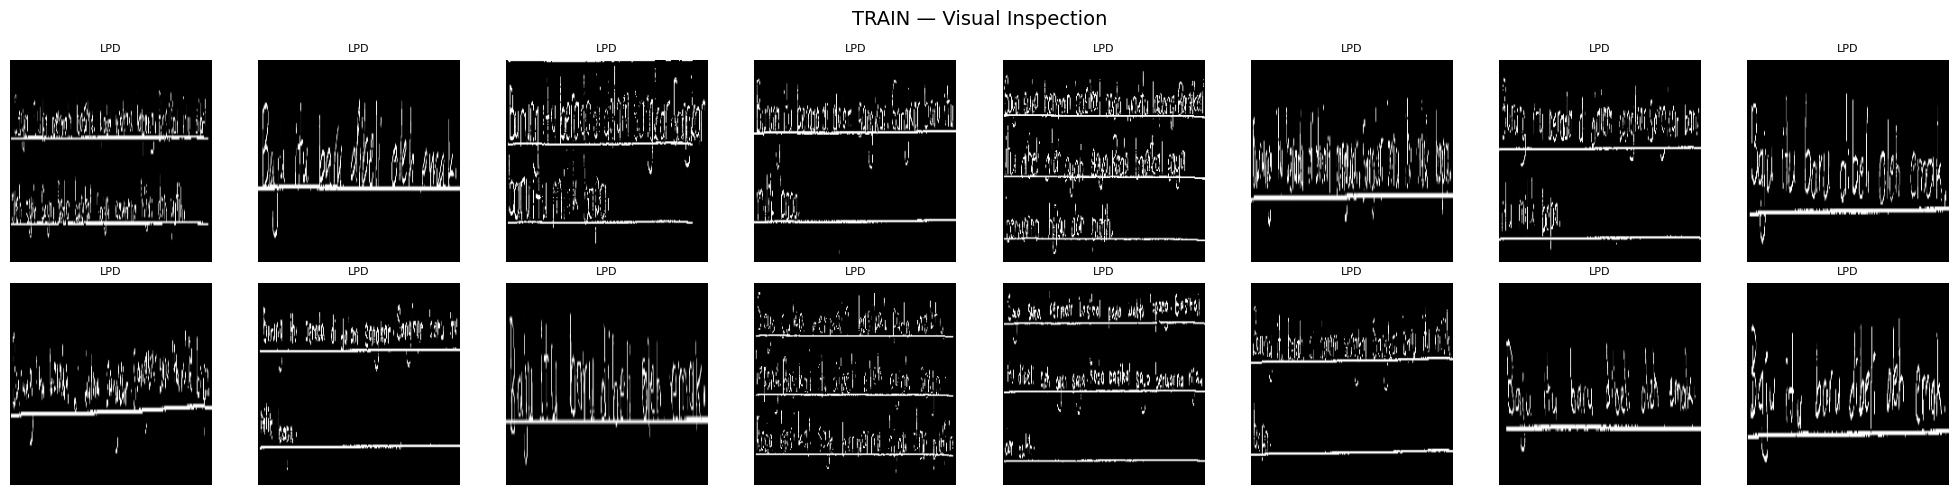

  ✓ train saved → ..\data\reports\visual_inspection_train.png


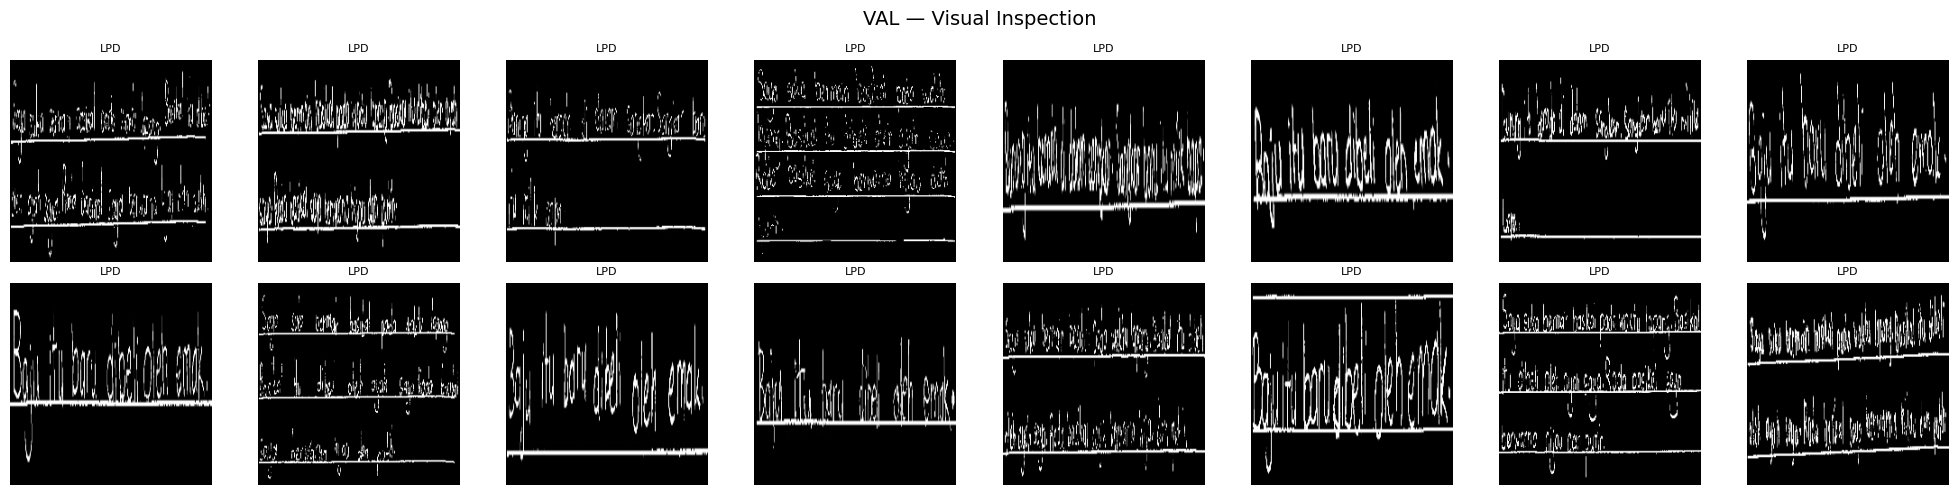

  ✓ val saved → ..\data\reports\visual_inspection_val.png


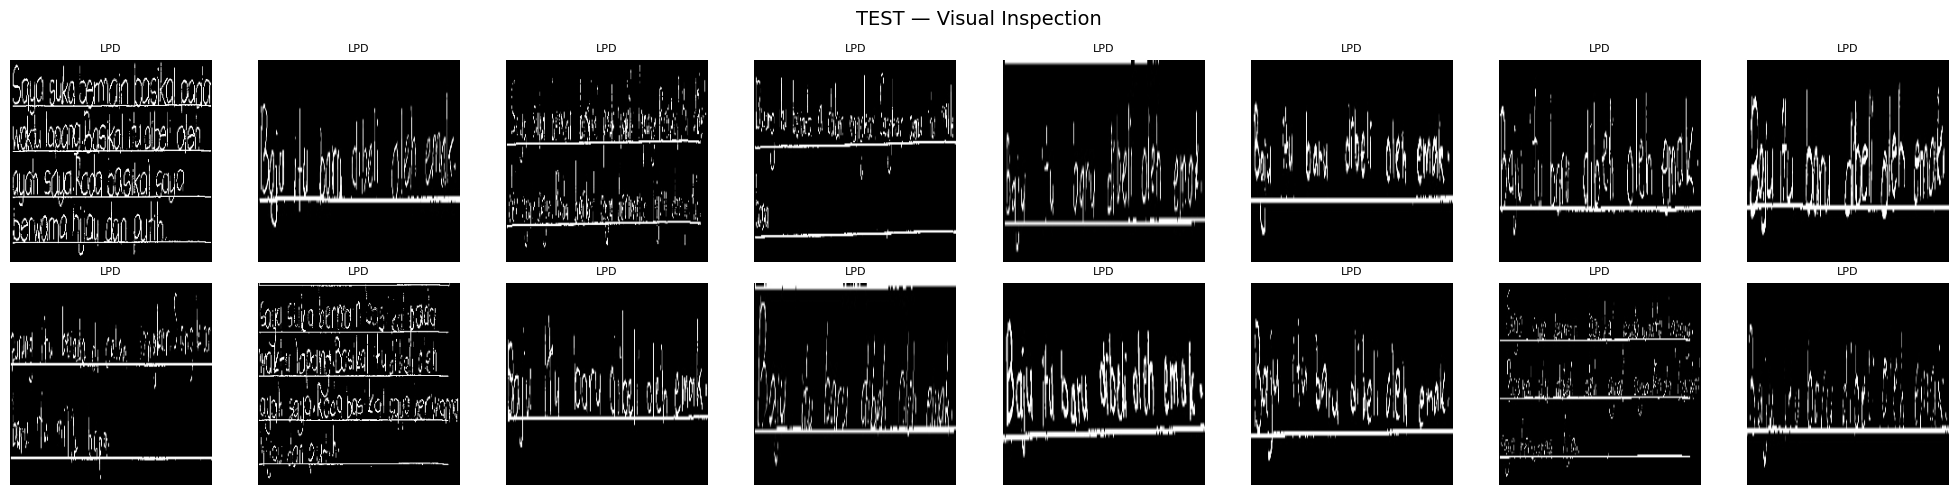

  ✓ test saved → ..\data\reports\visual_inspection_test.png


In [5]:
print("=" * 60)
print("STEP 4 — VISUAL INSPECTION (16 images per split)")
print("=" * 60)

for split in ["train", "val", "test"]:
    df  = pd.read_csv(os.path.join(MANIFEST_DIR, f"{split}.csv")).head(BATCH_SIZE)
    fig, axes = plt.subplots(2, 8, figsize=(20, 5))
    fig.suptitle(f"{split.upper()} — Visual Inspection", fontsize=14)

    for i, (_, row) in enumerate(df.iterrows()):
        ax = axes[i // 8][i % 8]
        try:
            img = load_image(row["image_path"])
            ax.imshow(img[..., 0], cmap="gray")
            ax.set_title(f"{'LPD' if row['label']==0 else 'PD'}", fontsize=8)
        except:
            ax.set_title("ERR", fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    save_path = os.path.join(REPORT_DIR, f"visual_inspection_{split}.png")
    plt.savefig(save_path)
    plt.show()
    print(f"  ✓ {split} saved → {save_path}")

results["visual"] = True

STEP 5 — AUGMENTED SAMPLE VALIDATION
  Total augmented samples: 0
  Issues: 0  ✓


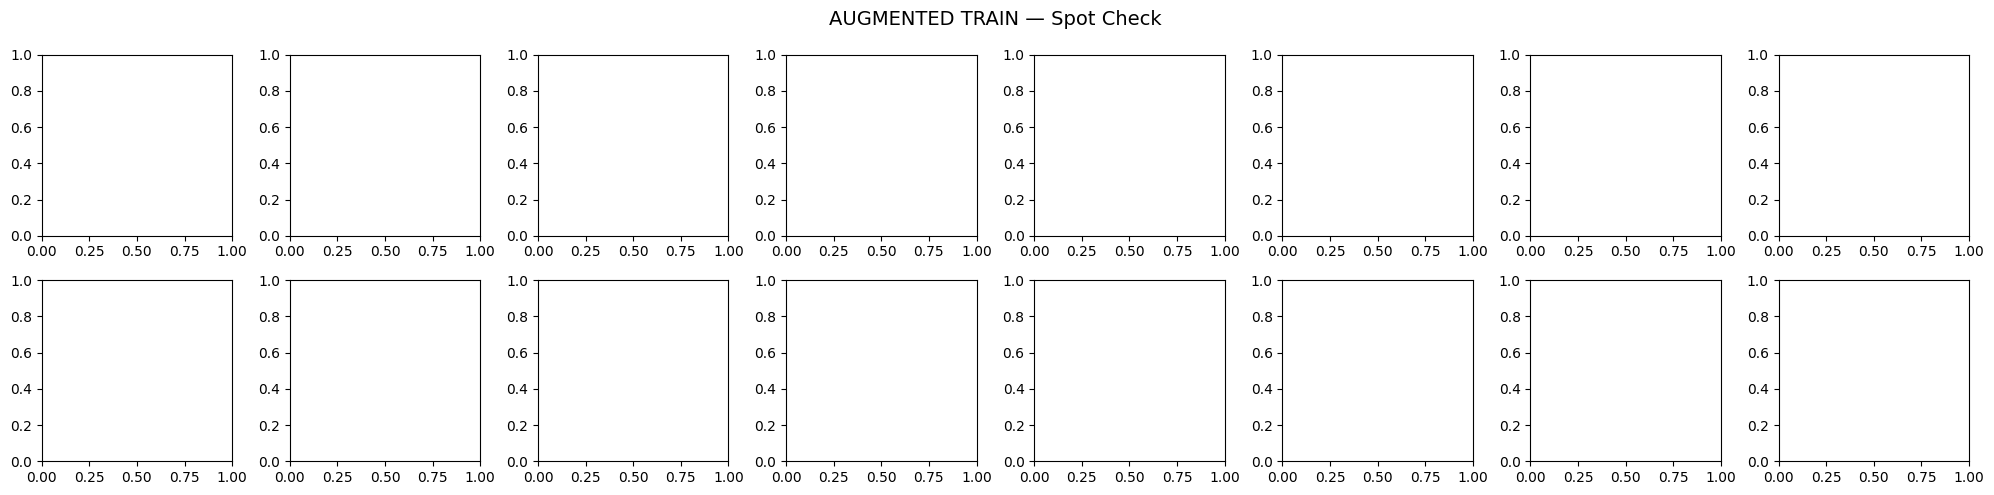

In [6]:
print("=" * 60)
print("STEP 5 — AUGMENTED SAMPLE VALIDATION")
print("=" * 60)

aug_df   = pd.read_csv(os.path.join(MANIFEST_DIR, "train_augmented.csv"))
aug_only = aug_df[aug_df["augmented"] == True]
sample   = aug_only.sample(min(BATCH_SIZE, len(aug_only)), random_state=42)

print(f"  Total augmented samples: {len(aug_only)}")

aug_issues = []
for _, row in sample.iterrows():
    try:
        img        = load_image(row["image_path"])
        arr        = img[..., 0]
        white_ratio = (arr > 0.5).mean()

        if arr.std() < 0.05:
            aug_issues.append((row["image_path"], "possibly blank"))
        if white_ratio < 0.01 or white_ratio > 0.99:
            aug_issues.append((row["image_path"], f"extreme pixel distribution: {white_ratio:.2f}"))
    except Exception as e:
        aug_issues.append((row["image_path"], str(e)))

ok = len(aug_issues) == 0
print(f"  Issues: {len(aug_issues)}  {'✓' if ok else '✗'}")

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle("AUGMENTED TRAIN — Spot Check", fontsize=14)

for i, (_, row) in enumerate(sample.iterrows()):
    ax = axes[i // 8][i % 8]
    try:
        img = load_image(row["image_path"])
        ax.imshow(img[..., 0], cmap="gray")
        ax.set_title(f"{'LPD' if row['label']==0 else 'PD'}", fontsize=8)
    except:
        ax.set_title("ERR", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "visual_inspection_augmented.png"))
plt.show()

results["augmentation"] = ok

In [7]:
print("=" * 60)
print("STEP 6 — PIPELINE VALIDATION REPORT")
print("=" * 60)

all_pass = all(results.values())

report = f"""# Pipeline Validation Report

## Summary

| Check | Result |
|-------|--------|
| Tensor Shape & DType | {'✓ PASS' if results['shape_dtype'] else '✗ FAIL'} |
| Pixel Range [0.0, 1.0] | {'✓ PASS' if results['pixel_range'] else '✗ FAIL'} |
| Label Encoding (0=LPD, 1=PD) | {'✓ PASS' if results['labels'] else '✗ FAIL'} |
| Visual Inspection | {'✓ PASS' if results['visual'] else '✗ FAIL'} |
| Augmented Sample Validation | {'✓ PASS' if results['augmentation'] else '✗ FAIL'} |
| **Overall** | **{'✓ ALL PASS — Ready for Phase 2' if all_pass else '✗ ISSUES FOUND'}** |

## Label Distribution

| Split | LPD (0) | PD (1) | Total |
|-------|---------|--------|-------|
"""

for split in ["train", "val", "test"]:
    df       = pd.read_csv(os.path.join(MANIFEST_DIR, f"{split}.csv"))
    lpd      = (df["label"] == 0).sum()
    pd_count = (df["label"] == 1).sum()
    report  += f"| {split} | {lpd} | {pd_count} | {len(df)} |\n"

aug_count = (aug_df["augmented"] == True).sum()
report += f"\n## Augmentation\n- Total augmented: {aug_count}\n"
report += f"- Applied to Training split ONLY ✓\n"
report += f"\n## Sign-off\n- Tag: v1.0-dataset-mendeley\n"
report += f"- Status: {'✓ APPROVED — Proceed to Phase 2' if all_pass else '✗ PENDING'}\n"

with open(f"{REPORT_DIR}/pipeline.md", "w", encoding="utf-8") as f:
    f.write(report)

print(f"✓ pipeline.md saved → {REPORT_DIR}/pipeline.md")
print(f"\nFinal Result: {'✓ ALL PASS' if all_pass else '✗ ISSUES FOUND'}")

STEP 6 — PIPELINE VALIDATION REPORT
✓ pipeline.md saved → ..\data\reports/pipeline.md

Final Result: ✓ ALL PASS
